In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime


In [3]:
start_data='2008-03-03'
end_data=datetime.today()
tickers=['^INDIAVIX','GC=F','INR=X','^GSPC','^IXIC','^NSEI','^VIX']
ind1y=pd.read_csv('India 1-Year Bond Yield Historical Data.csv')
ind3y=pd.read_csv('India 3-Year Bond Yield Historical Data.csv')
ind3m=pd.read_csv('India 3-Month Bond Yield Historical Data.csv')
us1y=pd.read_csv('United States 1-Year Bond Yield Historical Data.csv')
us3y=pd.read_csv('United States 3-Year Bond Yield Historical Data (1).csv')
us3m=pd.read_csv("United States 3-Month Bond Yield Historical Data (1).csv")

print(f'Today date-> {end_data}')

Today date-> 2026-06-08 15:14:46.412446


In [4]:
def modify_and_combine(df,name):
    if isinstance(df.columns,pd.MultiIndex):
        df.columns=df.columns.droplevel(1)
    else:
        print(f'No Multiindex')
    df=df[['Date','Price']].copy()
    df['Price']=df['Price']/100
    df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y',errors='coerce')
    df.set_index('Date',drop=True,inplace=True)
    
    df.rename(columns={'Price':name},inplace=True)
    
    

    return df


In [5]:
dfs=[ind1y,ind3m,ind3y,us1y,us3m,us3y]
names=['ind1y_1','ind3m_1','ind3y_1','us1y_1','us3m_1','us3y_1']
modified_df=[]

for df, name in zip(dfs, names):
    modified_df.append(modify_and_combine(df, name))

    

No Multiindex
No Multiindex
No Multiindex
No Multiindex
No Multiindex
No Multiindex


In [6]:
modified_df[0].index

DatetimeIndex(['2026-06-05', '2026-06-04', '2026-06-03', '2026-06-02',
               '2026-06-01', '2026-05-29', '2026-05-28', '2026-05-27',
               '2026-05-26', '2026-05-25',
               ...
               '2008-03-17', '2008-03-14', '2008-03-13', '2008-03-12',
               '2008-03-11', '2008-03-10', '2008-03-07', '2008-03-05',
               '2008-03-04', '2008-03-03'],
              dtype='datetime64[ns]', name='Date', length=4517, freq=None)

In [7]:
main_df1=pd.concat(modified_df,axis=1)

In [8]:
del main_df1['us1y_1'] #too many rows was null and hard to do ffill and bfill

In [9]:
main_df1=main_df1.ffill().bfill()

In [16]:
main_df2=yf.download(tickers,start=start_data,end=end_data)['Close']

[*********************100%***********************]  7 of 7 completed


In [17]:
if isinstance(main_df2.columns,pd.MultiIndex):
    main_df2.columns=main_df2.columns.droplevel(1)

else:
    print('No multiindex')

main_df2.index = pd.to_datetime(main_df2.index.date)

No multiindex


In [20]:
main_df=pd.concat([main_df1,main_df2],axis=1)

In [22]:
main_df=main_df.ffill().bfill()

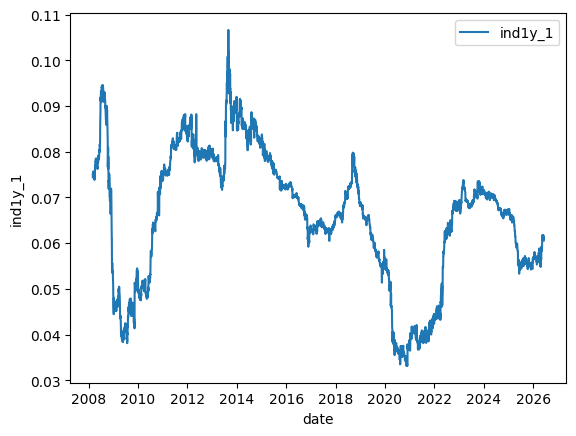

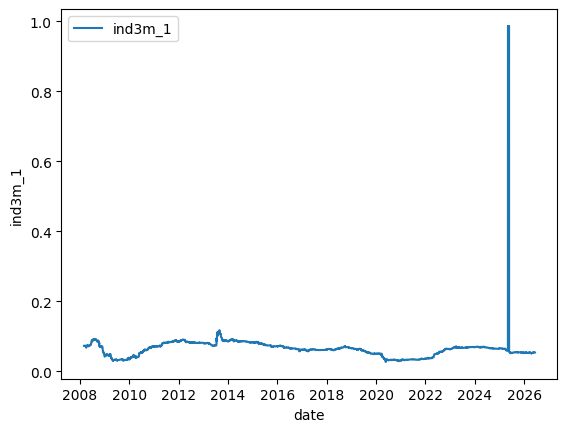

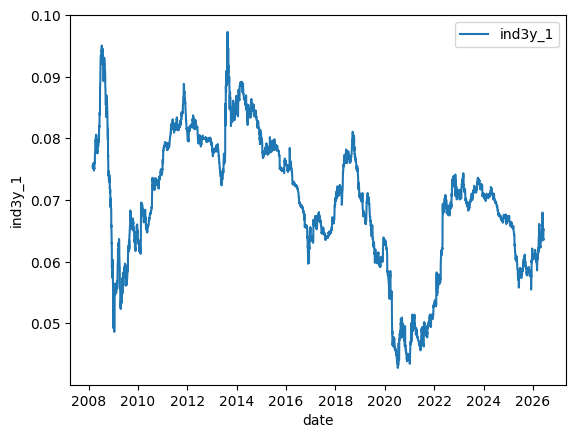

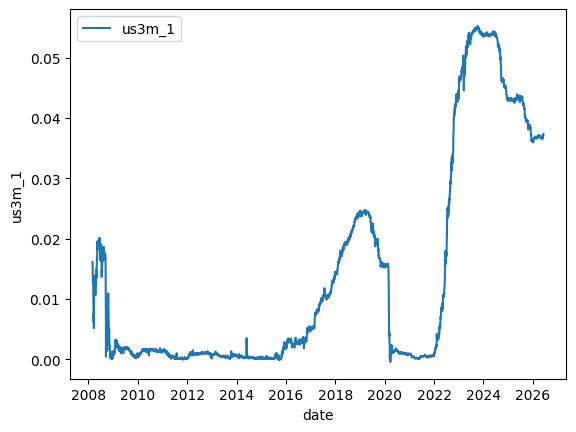

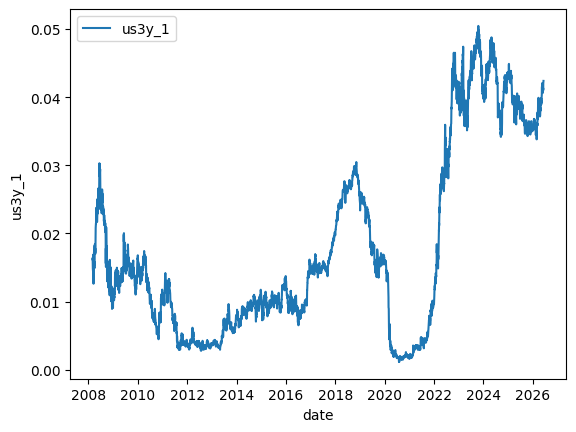

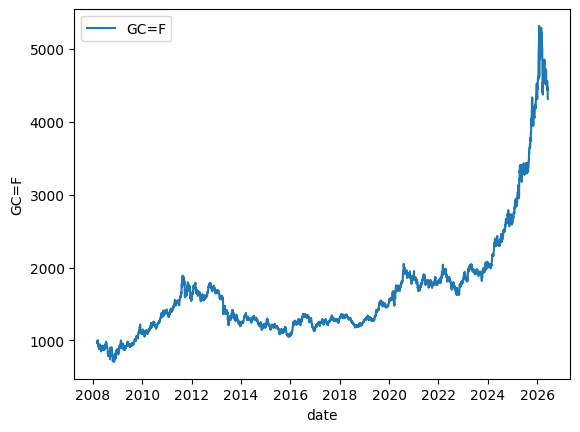

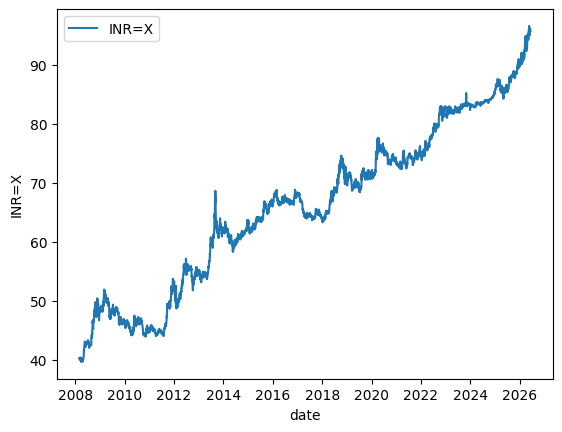

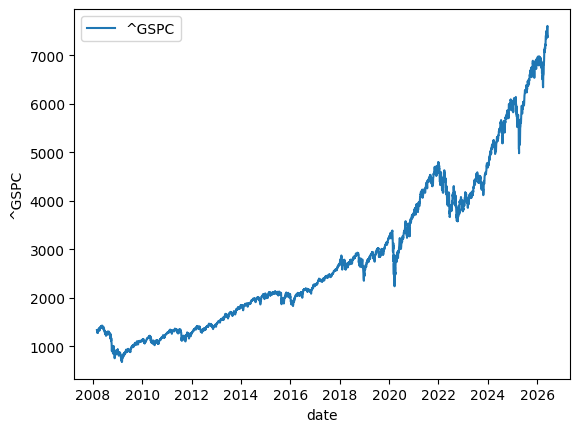

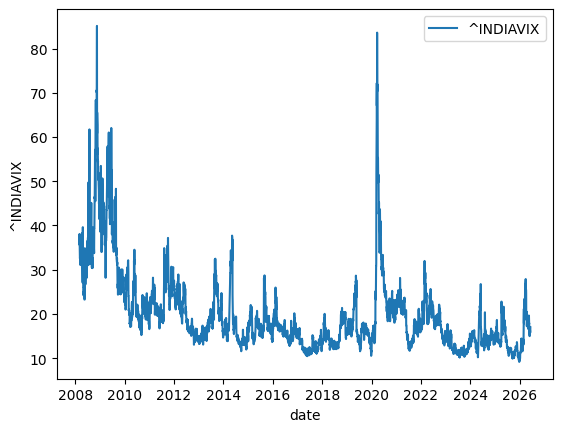

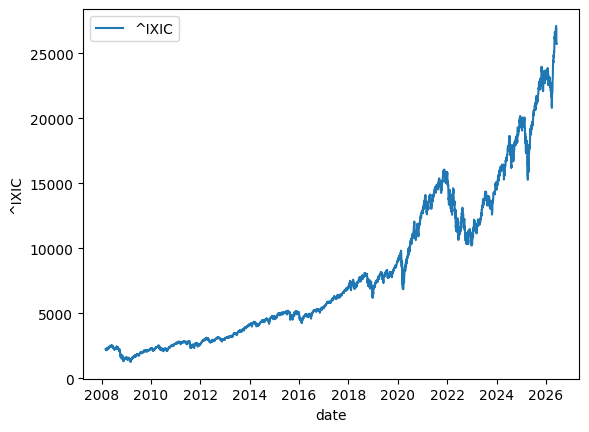

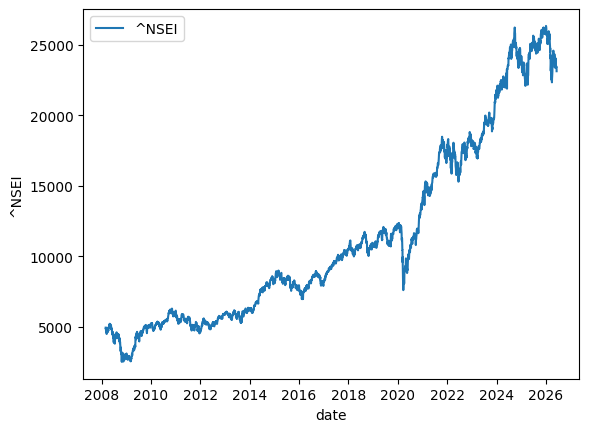

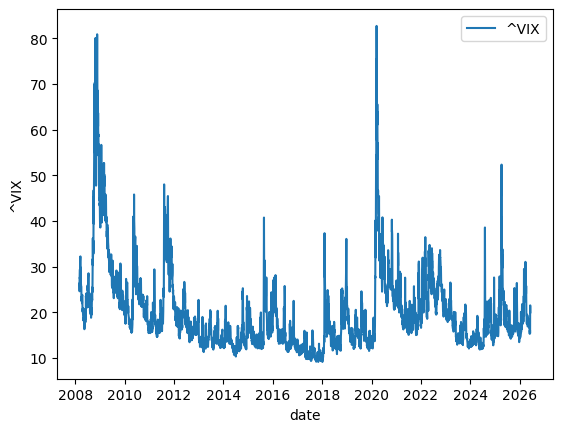

In [28]:
for cols in main_df.columns:
    plt.plot(main_df[cols],label=f'{cols}')
    plt.xlabel('date')
    plt.ylabel(f'{cols}')
    plt.legend()
    plt.show()

In [29]:
main_df.to_csv('main_df.csv')

output cleared 